# Final Open/Closed Thinking Analysis

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

import social_groups.polars_columns as plc
from social_groups.analysis.defs.notebooks.definitions import register_materialization
from social_groups.analysis.polars_transformations import (
    apply_parsing_and_group_decision,
)
from social_groups.analysis.polars_transformations.deserialize_experiment_configuration import (
    deserialize_experiment_configuration,
)
from social_groups.analysis.polars_transformations.make_group_constellation import (
    parse_parameters,
)
from social_groups.analysis.polars_transformations.wasserstein_distance import (
    calculate_wasserstein_distance,
)
from social_groups.polars_values import MODEL_NAME_TO_LETTER_MAPPING
from social_groups.reporting.group_reply import (
    GroupReplyAggregator,
    MajorityVote,
)
from social_groups.reporting.parsing import (
    AnswerComparer,
    AnswerOptions,
    AnswerParser,
)

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:398: BetaWarning: Class `Manager` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  MANAGER_FOR_NOTEBOOK_INSTANCE = Manager()
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:200: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:205: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterth

In [2]:
parser = AnswerParser(AnswerOptions.letters_A_to_J)
group_reply = GroupReplyAggregator(MajorityVote())
comparer = AnswerComparer(
    AnswerOptions.letters_A_to_J, triple_underscore_handling="wrong"
)

In [3]:
from social_groups.analysis.definitions import defs

thinking_mad_frame: pl.DataFrame = defs().load_asset_value("final_thinking_mad")
diversity_mad: pl.DataFrame = defs().load_asset_value("final_diversity_params")

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_config/pythonic_config/typing_utils.py:101: UserWarning: Field name "extension" in "PolarsParquetIOManager" shadows an attribute in parent "BasePolarsUPathIOManager"
  return super().__new__(cls, name, bases, namespaces, **kwargs)
2026-06-29 00:54:19 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_thinking_mad.parquet using PolarsParquetIOManager...
2026-06-29 00:54:21 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_diversity_params.parquet using PolarsParquetIOManager...


In [5]:
frame = (
    pl.concat(
        [
            thinking_mad_frame,
            diversity_mad.filter(temperature=0.0, top_p=1.0)
            .with_columns(
                closed_thinking_models=pl.col("model_names")
                .list.eval(pl.lit(None))
                .cast(pl.List(pl.String)),
                open_thinking_models=pl.col("model_names"),
                who_thinks_openly=pl.lit("all"),
            )
            .with_columns(
                closed_thinking_models_parameter=pl.col("closed_thinking_models")
                .list.eval(pl.lit(None))
                .cast(pl.List(pl.Float64)),
                open_thinking_models_parameter=pl.col("model_names")
                .list.eval(parse_parameters(pl.element()))
                .cast(pl.List(pl.Float64)),
            )
            .drop(["model_parameters", "sizes", "temperature", "top_p"]),
        ],
        how="align_full",
        strict=True,
    )
    .with_columns(
        pl.col("model_names").list.len().alias("group_size"),
        pl.col("model_names")
        .list.eval(pl.element().replace(MODEL_NAME_TO_LETTER_MAPPING))
        .list.join("")
        .alias("group_constellation"),
    )
    .filter(pl.col("group_size").is_in({2, 3}))
    .with_columns(
        pl.col("model_family").str.replace(
            "Ministral", "Ministral \n (only whitespace trimming)"
        )
    )
)

In [6]:
thinking_mad_parsed = apply_parsing_and_group_decision(
    frame, parser, comparer, group_reply
)

In [7]:
NUM_ROUNDS = thinking_mad_parsed["number_of_mad_rounds"].unique().item()

In [8]:
thinking_mad_results = (
    thinking_mad_parsed.group_by(
        [
            "model_names",
            "open_thinking_models",
            "closed_thinking_models",
            "model_family",
            "closed_thinking_models_parameter",
            "open_thinking_models_parameter",
            "who_thinks_openly",
            "group_size",
            "group_constellation",
        ]
    )
    .agg(
        pl.col("run_id").unique().item(),  # To assert correct aggregation
        pl.len().alias("len"),
        pl.col(plc.is_correct).mean().alias(plc.accuracy),
        pl.col(plc.used_input_tokens).mean(),
        pl.col(plc.used_output_tokens).mean(),
        (
            pl.col("___parsed_individual_answers_after___").list.count_matches(
                "___not_parsable___"
            )
            / pl.col("___parsed_individual_answers_after___").list.len()
        )
        .mean()
        .alias("amount_parsing_errors_after"),
        (
            pl.col("___parsed_individual_answers_before___").list.count_matches(
                "___not_parsable___"
            )
            / pl.col("___parsed_individual_answers_before___").list.len()
        )
        .mean()
        .alias("amount_parsing_errors_before"),
        comparer(
            pl.col(plc.parsed_combined_answers_before),
            pl.col(plc.answer_string),
        )
        .mean()
        .alias("accuracy_before"),
    )
    .sort(plc.accuracy, descending=True)
    .with_columns(
        call_cost_heuristic=pl.col("model_names")
        .list.eval(parse_parameters(pl.element()) * 2 * NUM_ROUNDS)
        .list.sum(),
        accuracy_increase=pl.col("accuracy") - pl.col("accuracy_before"),
    )
)

thinking_mad_results = thinking_mad_results.join(
    calculate_wasserstein_distance(
        thinking_mad_parsed.drop(
            "closed_thinking_models",
            "open_thinking_models",
            "open_thinking_models_parameter",
            "closed_thinking_models_parameter",
        ),
        group_reply,
        comparer,
        "run_id",
    ).select("run_id", pl.selectors.starts_with("wd")),
    on="run_id",
    validate="1:1",
).drop("run_id", "len")

thinking_mad_results

model_names,open_thinking_models,closed_thinking_models,model_family,closed_thinking_models_parameter,open_thinking_models_parameter,who_thinks_openly,group_size,group_constellation,accuracy,used_input_tokens,used_output_tokens,amount_parsing_errors_after,amount_parsing_errors_before,accuracy_before,call_cost_heuristic,accuracy_increase,wd_bias_good proposals,wd_bias_bad proposals,wd_bias_weight on one,wd_bias_False
list[str],list[str],list[str],str,list[f64],list[f64],str,u32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"[""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-4B""]","[null, null, null]","[""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-4B""]","""Qwen3.5""","[4.0, 9.0, 4.0]","[null, null, null]","""L""",3,"""MHM""",0.746667,61313.443333,29482.4,0.12,0.174444,0.69,102.0,0.056667,0.197164,0.38462,0.344714,0.290892
"[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B""]","[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B""]","[null, null]","""Qwen3""","[null, null]","[0.6, 0.6]","""L""",2,"""LL""",0.22,21061.63,6105.1,0.055,0.195,0.21,7.2,0.01,0.2604,0.44236,0.3496,0.35138
"[""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-4B""]","[null, ""Qwen/Qwen3.5-9B"", null]","[""Qwen/Qwen3.5-0.8B"", null, ""Qwen/Qwen3.5-4B""]","""Qwen3.5""","[0.8, null, 4.0]","[null, 9.0, null]","""H""",3,"""LHM""",0.746667,66097.6,24380.756667,0.143333,0.235556,0.636667,82.8,0.11,0.174956,0.366584,0.301372,0.27077
"[""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512""]","[null, null, null]","[""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512""]","""Ministral (only whitespace t…","[14.0, 14.0, 14.0]","[null, null, null]","""none""",3,"""HHH""",0.716667,28980.406667,5944.16,0.018889,0.061111,0.686667,252.0,0.03,0.174199,0.40152,0.302404,0.287859
"[""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-4B""]","[null, null, null]","[""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-4B""]","""Qwen3.5""","[4.0, 9.0, 4.0]","[null, null, null]","""none""",3,"""MHM""",0.75,61046.283333,29702.346667,0.131111,0.183333,0.68,102.0,0.07,0.200271,0.373413,0.363714,0.286842
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"[""Qwen/Qwen3-4B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B""]","[null, null, ""Qwen/Qwen3-14B""]","[""Qwen/Qwen3-4B"", ""Qwen/Qwen3-0.6B"", null]","""Qwen3""","[4.0, 0.6, null]","[null, null, 14.0]","""H""",3,"""MLH""",0.776667,28978.406667,7968.533333,0.023333,0.108889,0.653333,111.6,0.123333,0.138012,0.358895,0.252593,0.248453
"[""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-0.8B""]","[null, null, null]","[""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-0.8B""]","""Qwen3.5""","[9.0, 9.0, 0.8]","[null, null, null]","""none""",3,"""HHL""",0.72,56085.9,24341.75,0.155556,0.211111,0.643333,112.8,0.076667,0.206367,0.390362,0.347231,0.298365
"[""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-4B""]","[null, null]","[""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-4B""]","""Qwen3.5""","[4.0, 4.0]","[null, null]","""L""",2,"""MM""",0.676667,34072.66,20253.076667,0.123333,0.175,0.606667,48.0,0.07,0.173542,0.339723,0.215085,0.256632


In [9]:
PKS = [
    "model_names",
    # "open_thinking_models",
    # "closed_thinking_models",
    "model_family",
    # "closed_thinking_models_parameter",
    # "open_thinking_models_parameter",
    "group_size",
    "group_constellation",
]


SETTING = "who_thinks_openly"

METRICS = [
    "accuracy",
    "used_input_tokens",
    "used_output_tokens",
    "amount_parsing_errors_after",
    "amount_parsing_errors_before",
    "accuracy_before",
    "call_cost_heuristic",
    "accuracy_increase",
    "wd_bias_good proposals",
    "wd_bias_bad proposals",
    "wd_bias_weight on one",
    "wd_bias_False",
]

In [10]:
thinking_mad_results.group_by("model_family", "who_thinks_openly", "group_size").agg(
    pl.col("group_constellation").len()
)

model_family,who_thinks_openly,group_size,group_constellation
str,str,u32,u32
"""Ministral (only whitespace t…","""H""",3,27
"""Qwen3""","""all""",3,10
"""Ministral (only whitespace t…","""all""",2,6
"""Qwen3.5""","""H""",3,27
"""Ministral (only whitespace t…","""all""",3,10
…,…,…,…
"""Qwen3""","""L""",2,9
"""Qwen3""","""none""",3,27
"""Qwen3.5""","""L""",2,9


In [11]:
fully_available_groups = set(
    thinking_mad_results.filter(pl.col("who_thinks_openly") == "all")[
        "group_constellation"
    ]
    .unique()
    .to_list()
)
fully_available_thinking_mad_results = thinking_mad_results.filter(
    pl.col("group_constellation").is_in(fully_available_groups)
)
fully_available_thinking_mad_results

model_names,open_thinking_models,closed_thinking_models,model_family,closed_thinking_models_parameter,open_thinking_models_parameter,who_thinks_openly,group_size,group_constellation,accuracy,used_input_tokens,used_output_tokens,amount_parsing_errors_after,amount_parsing_errors_before,accuracy_before,call_cost_heuristic,accuracy_increase,wd_bias_good proposals,wd_bias_bad proposals,wd_bias_weight on one,wd_bias_False
list[str],list[str],list[str],str,list[f64],list[f64],str,u32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B""]","[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B""]","[null, null]","""Qwen3""","[null, null]","[0.6, 0.6]","""L""",2,"""LL""",0.22,21061.63,6105.1,0.055,0.195,0.21,7.2,0.01,0.2604,0.44236,0.3496,0.35138
"[""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512""]","[null, null, null]","[""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512""]","""Ministral (only whitespace t…","[14.0, 14.0, 14.0]","[null, null, null]","""none""",3,"""HHH""",0.716667,28980.406667,5944.16,0.018889,0.061111,0.686667,252.0,0.03,0.174199,0.40152,0.302404,0.287859
"[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-4B""]","[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B"", null]","[null, null, ""Qwen/Qwen3-4B""]","""Qwen3""","[null, null, 4.0]","[0.6, 0.6, null]","""L""",3,"""LLM""",0.486667,35739.073333,9586.193333,0.038889,0.145556,0.333333,31.2,0.153333,0.223965,0.425901,0.321951,0.324933
"[""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-4B""]","[""Qwen/Qwen3.5-9B"", null, null]","[null, ""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-4B""]","""Qwen3.5""","[null, 0.8, 4.0]","[9.0, null, null]","""H""",3,"""HLM""",0.743333,67872.823333,25090.843333,0.15,0.232222,0.613333,82.8,0.13,0.171426,0.355451,0.28869,0.263438
"[""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-4B""]","[""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-4B""]","[null, null, null]","""Qwen3.5""","[null, null, null]","[0.8, 4.0, 4.0]","""all""",3,"""LMM""",0.706667,75646.333333,24952.923333,0.135556,0.225556,0.61,52.8,0.096667,0.174905,0.366703,0.301381,0.270804
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-4B""]","[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-4B""]","[null, null, null]","""Qwen3""","[null, null, null]","[14.0, 0.6, 4.0]","""all""",3,"""HLM""",0.74,36592.56,8519.803333,0.022222,0.11,0.65,111.6,0.09,0.1653,0.392681,0.362041,0.27899
"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B""]","[null, null, null]","[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B""]","""Qwen3""","[14.0, 0.6, 0.6]","[null, null, null]","""none""",3,"""HLL""",0.536667,27851.98,10710.163333,0.081111,0.134444,0.38,91.2,0.156667,0.211442,0.427005,0.341517,0.319223
"[""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-0.8B""]","[""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-0.8B""]","[null, null]","""Qwen3.5""","[null, null]","[0.8, 0.8]","""L""",2,"""LL""",0.286667,27875.35,9812.84,0.365,0.34,0.263333,9.6,0.023333,0.220941,0.431141,0.30944,0.326041


In [12]:
fully_available_thinking_mad_results.group_by(
    "group_constellation", "model_family"
).agg(
    x
    for m in METRICS
    for x in [
        pl.col(m).max().name.suffix(f"_max"),
        pl.col(m).min().name.suffix(f"_min"),
        (pl.col(m).max() - pl.col(m).min()).name.suffix(f"_spread"),
    ]
)

group_constellation,model_family,accuracy_max,accuracy_min,accuracy_spread,used_input_tokens_max,used_input_tokens_min,used_input_tokens_spread,used_output_tokens_max,used_output_tokens_min,used_output_tokens_spread,amount_parsing_errors_after_max,amount_parsing_errors_after_min,amount_parsing_errors_after_spread,amount_parsing_errors_before_max,amount_parsing_errors_before_min,amount_parsing_errors_before_spread,accuracy_before_max,accuracy_before_min,accuracy_before_spread,call_cost_heuristic_max,call_cost_heuristic_min,call_cost_heuristic_spread,accuracy_increase_max,accuracy_increase_min,accuracy_increase_spread,wd_bias_good proposals_max,wd_bias_good proposals_min,wd_bias_good proposals_spread,wd_bias_bad proposals_max,wd_bias_bad proposals_min,wd_bias_bad proposals_spread,wd_bias_weight on one_max,wd_bias_weight on one_min,wd_bias_weight on one_spread,wd_bias_False_max,wd_bias_False_min,wd_bias_False_spread
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""LLM""","""Ministral (only whitespace t…",0.55,0.513333,0.036667,30429.11,29523.24,905.87,6210.973333,6015.59,195.383333,0.183333,0.155556,0.027778,0.16,0.141111,0.018889,0.48,0.443333,0.036667,84.0,84.0,0.0,0.1,0.033333,0.066667,0.275705,0.256871,0.018834,0.439931,0.423432,0.016498,0.32407,0.307364,0.016706,0.357818,0.341247,0.01657
"""HLM""","""Qwen3""",0.753333,0.73,0.023333,36592.56,25027.15,11565.41,9288.523333,8519.803333,768.72,0.048889,0.022222,0.026667,0.127778,0.11,0.017778,0.663333,0.64,0.023333,111.6,111.6,0.0,0.113333,0.07,0.043333,0.175105,0.158575,0.01653,0.401506,0.36204,0.039467,0.362041,0.256144,0.105897,0.281712,0.260307,0.021405
"""HLM""","""Ministral (only whitespace t…",0.636667,0.613333,0.023333,30364.173333,29715.873333,648.3,6501.44,6243.986667,257.453333,0.097778,0.067778,0.03,0.115556,0.093333,0.022222,0.59,0.55,0.04,150.0,150.0,0.0,0.063333,0.04,0.023333,0.245662,0.221528,0.024134,0.459454,0.43818,0.021274,0.382781,0.374198,0.008583,0.352558,0.329854,0.022704
"""HM""","""Ministral (only whitespace t…",0.63,0.596667,0.033333,16712.91,16502.433333,210.476667,4062.436667,3940.293333,122.143333,0.065,0.045,0.02,0.096667,0.078333,0.018333,0.553333,0.506667,0.046667,132.0,132.0,0.0,0.103333,0.066667,0.036667,0.214791,0.203141,0.01165,0.40019,0.385825,0.014365,0.271304,0.248216,0.023088,0.306684,0.294582,0.012102
"""HHH""","""Qwen3""",0.79,0.756667,0.033333,35459.29,22065.763333,13393.526667,8866.956667,8811.013333,55.943333,0.046667,0.032222,0.014444,0.072222,0.066667,0.005556,0.763333,0.743333,0.02,252.0,252.0,0.0,0.036667,-0.006667,0.043333,0.211299,0.148199,0.0631,0.445718,0.375803,0.069914,0.439214,0.288121,0.151093,0.324936,0.262001,0.062935
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""HHH""","""Ministral (only whitespace t…",0.716667,0.676667,0.04,29451.66,28914.786667,536.873333,6189.836667,5944.16,245.676667,0.035556,0.018889,0.016667,0.066667,0.061111,0.005556,0.69,0.673333,0.016667,252.0,252.0,0.0,0.03,0.003333,0.026667,0.21018,0.173369,0.036812,0.424683,0.40152,0.023163,0.341082,0.302404,0.038678,0.317432,0.287859,0.029572
"""MM""","""Qwen3.5""",0.703333,0.676667,0.026667,44010.553333,32513.74,11496.813333,20253.076667,19943.176667,309.9,0.123333,0.076667,0.046667,0.198333,0.171667,0.026667,0.623333,0.59,0.033333,48.0,48.0,0.0,0.1,0.07,0.03,0.173542,0.159374,0.014168,0.339723,0.314429,0.025294,0.233194,0.191526,0.041668,0.256632,0.241256,0.015376
"""MM""","""Ministral (only whitespace t…",0.556667,0.53,0.026667,16141.2,15701.17,440.03,3792.556667,3572.68,219.876667,0.118333,0.09,0.028333,0.111667,0.096667,0.015,0.543333,0.52,0.023333,96.0,96.0,0.0,0.02,0.0,0.02,0.234486,0.196727,0.037759,0.42623,0.376393,0.049837,0.340154,0.229558,0.110596,0.329249,0.28656,0.042689


In [13]:
thinking_mad_results.schema

Schema([('model_names', List(String)),
        ('open_thinking_models', List(String)),
        ('closed_thinking_models', List(String)),
        ('model_family', String),
        ('closed_thinking_models_parameter', List(Float64)),
        ('open_thinking_models_parameter', List(Float64)),
        ('who_thinks_openly', String),
        ('group_size', UInt32),
        ('group_constellation', String),
        ('accuracy', Float64),
        ('used_input_tokens', Float64),
        ('used_output_tokens', Float64),
        ('amount_parsing_errors_after', Float64),
        ('amount_parsing_errors_before', Float64),
        ('accuracy_before', Float64),
        ('call_cost_heuristic', Float64),
        ('accuracy_increase', Float64),
        ('wd_bias_good proposals', Float64),
        ('wd_bias_bad proposals', Float64),
        ('wd_bias_weight on one', Float64),
        ('wd_bias_False', Float64)])

In [14]:
thinking_mad_results.filter(pl.col("who_thinks_openly") != "all").group_by(
    "group_constellation", "model_family"
).agg(
    x
    for m in METRICS
    for x in [
        pl.col(m).max().name.suffix(f"_max"),
        pl.col(m).min().name.suffix(f"_min"),
        (pl.col(m).max() - pl.col(m).min()).name.suffix(f"_spread"),
    ]
)

group_constellation,model_family,accuracy_max,accuracy_min,accuracy_spread,used_input_tokens_max,used_input_tokens_min,used_input_tokens_spread,used_output_tokens_max,used_output_tokens_min,used_output_tokens_spread,amount_parsing_errors_after_max,amount_parsing_errors_after_min,amount_parsing_errors_after_spread,amount_parsing_errors_before_max,amount_parsing_errors_before_min,amount_parsing_errors_before_spread,accuracy_before_max,accuracy_before_min,accuracy_before_spread,call_cost_heuristic_max,call_cost_heuristic_min,call_cost_heuristic_spread,accuracy_increase_max,accuracy_increase_min,accuracy_increase_spread,wd_bias_good proposals_max,wd_bias_good proposals_min,wd_bias_good proposals_spread,wd_bias_bad proposals_max,wd_bias_bad proposals_min,wd_bias_bad proposals_spread,wd_bias_weight on one_max,wd_bias_weight on one_min,wd_bias_weight on one_spread,wd_bias_False_max,wd_bias_False_min,wd_bias_False_spread
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""LLM""","""Qwen3.5""",0.69,0.663333,0.026667,57839.586667,57141.166667,698.42,20232.65,19949.316667,283.333333,0.185556,0.154444,0.031111,0.315556,0.275556,0.04,0.476667,0.43,0.046667,33.6,33.6,0.0,0.24,0.213333,0.026667,0.17796,0.169768,0.008191,0.355817,0.323755,0.032063,0.266798,0.262441,0.004358,0.266889,0.250494,0.016395
"""HMM""","""Qwen3.5""",0.746667,0.733333,0.013333,70412.39,59728.816667,10683.573333,30458.866667,29397.99,1060.876667,0.147778,0.113333,0.034444,0.184444,0.164444,0.02,0.7,0.653333,0.046667,102.0,102.0,0.0,0.093333,0.046667,0.046667,0.211722,0.183335,0.028387,0.39375,0.367836,0.025913,0.358349,0.345078,0.013271,0.302736,0.275586,0.02715
"""HHM""","""Ministral (only whitespace t…",0.676667,0.653333,0.023333,29807.243333,29337.146667,470.096667,6345.196667,6222.526667,122.67,0.048889,0.034444,0.014444,0.087778,0.07,0.017778,0.663333,0.656667,0.006667,216.0,216.0,0.0,0.02,-0.003333,0.023333,0.23209,0.217385,0.014705,0.456467,0.438121,0.018346,0.390573,0.352216,0.038357,0.344279,0.327753,0.016526
"""MHH""","""Qwen3""",0.786667,0.763333,0.023333,31695.063333,23151.416667,8543.646667,9169.763333,8377.626667,792.136667,0.043333,0.034444,0.008889,0.085556,0.065556,0.02,0.76,0.74,0.02,192.0,192.0,0.0,0.036667,0.003333,0.033333,0.196386,0.167849,0.028536,0.410813,0.388411,0.022402,0.329962,0.32072,0.009242,0.303599,0.27813,0.025469
"""LM""","""Qwen3.5""",0.63,0.61,0.02,31112.806667,30787.866667,324.94,14836.23,14682.036667,154.193333,0.158333,0.15,0.008333,0.261667,0.25,0.011667,0.48,0.446667,0.033333,28.8,28.8,0.0,0.176667,0.13,0.046667,0.170155,0.158016,0.012139,0.332404,0.301414,0.03099,0.230384,0.175785,0.054599,0.251279,0.229715,0.021564
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ML""","""Qwen3""",0.47,0.41,0.06,17928.76,14816.433333,3112.326667,7229.183333,6135.67,1093.513333,0.085,0.051667,0.033333,0.158333,0.12,0.038333,0.336667,0.28,0.056667,27.6,27.6,0.0,0.176667,0.11,0.066667,0.235233,0.202064,0.03317,0.390404,0.380486,0.009918,0.272179,0.235867,0.036312,0.312819,0.291275,0.021544
"""LH""","""Qwen3""",0.72,0.496667,0.223333,17666.99,14996.26,2670.73,6394.703333,5319.973333,1074.73,0.05,0.016667,0.033333,0.136667,0.12,0.016667,0.37,0.34,0.03,87.6,87.6,0.0,0.35,0.156667,0.193333,0.179679,0.117054,0.062625,0.372772,0.316754,0.056018,0.210779,0.1012,0.109579,0.276226,0.216904,0.059322
"""MLH""","""Qwen3.5""",0.756667,0.743333,0.013333,64449.296667,57318.92,7130.376667,24330.71,23566.5,764.21,0.126667,0.104444,0.022222,0.234444,0.221111,0.013333,0.663333,0.583333,0.08,82.8,82.8,0.0,0.173333,0.086667,0.086667,0.176429,0.136019,0.04041,0.355583,0.304731,0.050853,0.317602,0.238358,0.079243,0.266006,0.220375,0.045631


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_thinking_mad/sensitivity_to_open_thinking_configuration.png


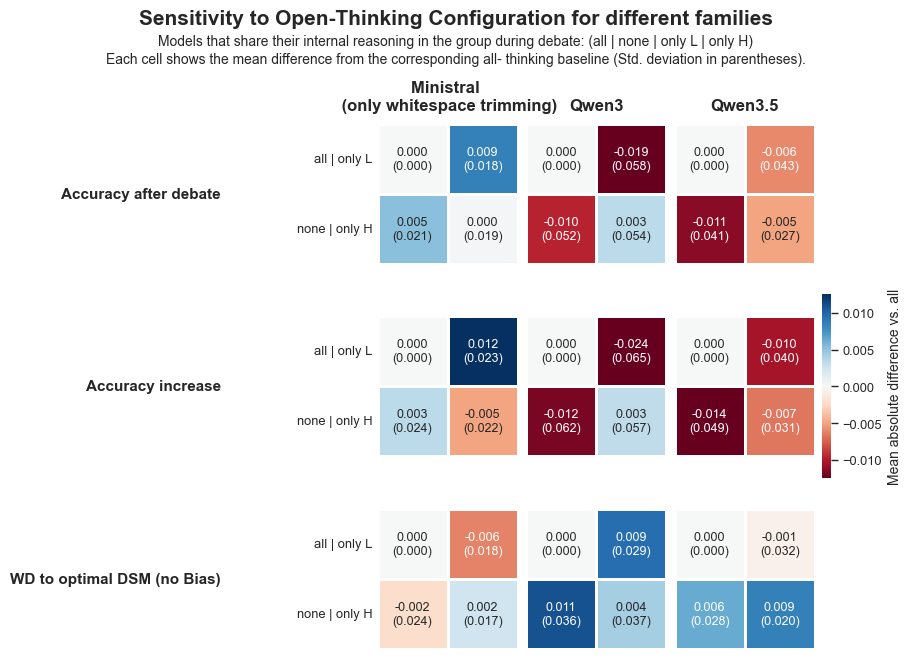

In [37]:
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.05,
)

metrics = [
    "accuracy",
    "accuracy_increase",
    "wd_bias_False",
]

metric_labels = {
    "accuracy": "Accuracy after debate",
    "accuracy_increase": "Accuracy increase",
    "wd_bias_False": "WD to optimal DSM (no Bias)",
    "accuracy_before": "Accuracy before debate",
}

who_grid = [["all", "L"], ["none", "H"]]

instance_cols = [
    "model_family",
    "group_size",
    "group_constellation",
]

df = thinking_mad_results

long = df.select(instance_cols + ["who_thinks_openly"] + metrics).unpivot(
    index=instance_cols + ["who_thinks_openly"],
    on=metrics,
    variable_name="metric",
    value_name="value",
)

baseline = long.filter(pl.col("who_thinks_openly") == "all").select(
    instance_cols + ["metric", pl.col("value").alias("all_value")]
)

diffs = (
    long.join(baseline, on=instance_cols + ["metric"], how="inner")
    .with_columns((pl.col("value") - pl.col("all_value")).alias("abs_diff"))
    .group_by(["metric", "model_family", "who_thinks_openly"])
    .agg(
        pl.mean("abs_diff").alias("mean_abs_diff"),
        pl.std("abs_diff").alias("std_abs_diff"),
    )
)

pdf = diffs.to_pandas()

families = sorted(pdf["model_family"].unique())
n_rows = len(metrics)
n_cols = len(families)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.0 * n_cols, 2 * n_rows),
    # squeeze=False,
    constrained_layout=True,
)

vmax = pdf["mean_abs_diff"].max()

for i, metric in enumerate(metrics):
    for j, family in enumerate(families):
        ax = axes[i, j]

        sub = pdf[(pdf["metric"] == metric) & (pdf["model_family"] == family)]

        heat_values = pd.DataFrame(
            index=["All models open", "No models open"],
            columns=["All models open", "Low-param open"],
            dtype=float,
        )

        heat_annot = pd.DataFrame(
            index=heat_values.index,
            columns=heat_values.columns,
            dtype=object,
        )

        for r in range(2):
            for c in range(2):
                who = who_grid[r][c]

                row = sub.loc[sub["who_thinks_openly"] == who]

                mean = row["mean_abs_diff"].item()

                std = row["std_abs_diff"].item()

                heat_values.iloc[r, c] = mean

                heat_annot.iloc[r, c] = f"{mean:.3f}\n({std:.3f})"

        sns.heatmap(
            heat_values,
            annot=heat_annot,
            fmt="",
            cmap="RdBu",
            cbar=((j == (n_cols - 1)) and (i == 1)),
            cbar_kws={"label": "Mean absolute difference vs. all"},
            square=True,
            linewidths=0.8,
            linecolor="white",
            ax=ax,
            vmin=-vmax,
            vmax=vmax,
            annot_kws={"fontsize": 9},
        )

        if j == 0:
            ax.set_yticklabels(
                [" | only ".join(who_grid[0]), " | only ".join(who_grid[1])], rotation=0
            )
        else:
            ax.set_yticklabels(["", ""], rotation=0)
        ax.set_xticklabels(["", ""], rotation=0)

        if i == 0:
            ax.set_title(
                family,
                fontsize=12,
                fontweight="bold",
                pad=10,
            )

        if j == 0:
            ax.set_ylabel(
                metric_labels.get(metric, metric),
                fontsize=11,
                fontweight="bold",
                rotation=0,
                ha="right",
                va="center",
                labelpad=55,
            )
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        ax.tick_params(length=0)

fig.suptitle(
    "Sensitivity to Open-Thinking Configuration for different families",
    fontsize=15,
    fontweight="bold",
    y=1.11,  # Move title up
)

fig.text(
    0.5,
    1.05,
    "Models that share their internal reasoning in the group during debate: (all | none | only L | only H)",
    ha="center",
    fontsize=10,
)

fig.text(
    0.5,
    1.02,
    "Each cell shows the mean difference from the corresponding all- thinking baseline (Std. deviation in parentheses).",
    ha="center",
    fontsize=10,
)


register_materialization(
    "sensitivity_to_open_thinking_configuration",
    fig,
    "sensitivity_to_open_thinking_configuration",
    force=True,
)

In [16]:
thinking_mad_results.with_columns(
    pl.col("group_constellation")
    .str.split("")
    .list.sort()
    .list.join("")
    .alias("group_configuration")
).group_by("model_family", "who_thinks_openly", "group_configuration").agg(
    pl.col(metrics)
)

model_family,who_thinks_openly,group_configuration,accuracy,accuracy_increase,wd_bias_False
str,str,str,list[f64],list[f64],list[f64]
"""Qwen3.5""","""L""","""MMM""",[0.73],[0.073333],[0.29776]
"""Ministral (only whitespace t…","""H""","""HHM""","[0.68, 0.676667, 0.7]","[0.023333, 0.02, 0.01]","[0.313146, 0.332255, 0.322056]"
"""Ministral (only whitespace t…","""all""","""HLL""",[0.563333],[0.093333],[0.363927]
"""Qwen3.5""","""all""","""MM""",[0.69],[0.1],[0.241256]
"""Qwen3""","""none""","""HHH""",[0.756667],[-0.006667],[0.321577]
…,…,…,…,…,…
"""Qwen3""","""all""","""HH""",[0.77],[0.036667],[0.276373]
"""Qwen3.5""","""all""","""HHM""",[0.726667],[0.036667],[0.330274]
"""Qwen3""","""none""","""HMM""","[0.756667, 0.763333, 0.756667]","[0.023333, 0.06, 0.056667]","[0.280527, 0.282667, 0.293429]"


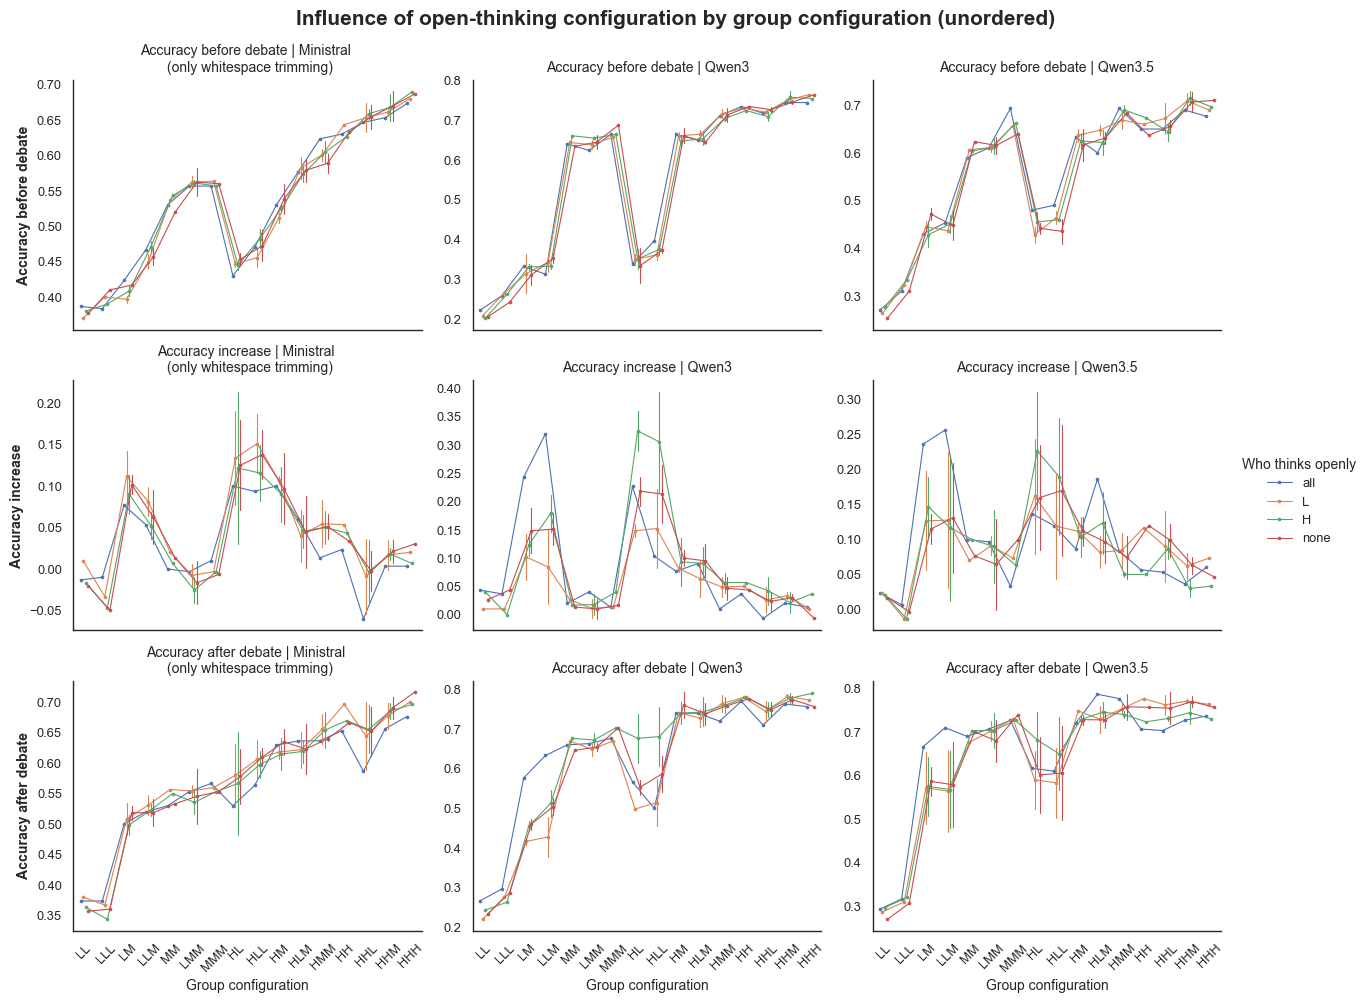

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_thinking_mad/influence_of_open_thinking_configuration_unordered_configuration.png


In [17]:
df = thinking_mad_results.with_columns(
    pl.col("group_constellation")
    .str.split("")
    .list.sort()
    .list.join("")
    .alias("group_configuration")
)

metrics = ["accuracy_before", "accuracy_increase", "accuracy"]

long = df.select(
    [
        "model_family",
        "group_configuration",
        "who_thinks_openly",
        *metrics,
    ]
).unpivot(
    index=[
        "model_family",
        "group_configuration",
        "who_thinks_openly",
    ],
    on=metrics,
    variable_name="metric",
    value_name="value",
)

pdf = long.to_pandas().sort_values(by="model_family")
config_order = sorted(
    pdf["group_configuration"].unique(),
    key=lambda x: (x.count("H"), x.count("M"), x.count("L"), x),
)
who_order = ["all", "L", "H", "none"]

g = sns.catplot(
    data=pdf,
    kind="point",
    x="group_configuration",
    y="value",
    hue="who_thinks_openly",
    col="model_family",
    row="metric",
    order=config_order,
    hue_order=who_order,
    dodge=0.35,
    markers="o",
    linestyles="-",
    errorbar="sd",  # or ("ci", 95)
    height=3.2,
    aspect=1.3,
    sharey=False,
    linewidth=0.8,
    row_order=metrics,
)

g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_axis_labels("Group configuration", "")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)

# Replace row titles with prettier labels
for ax, metric in zip(g.axes[:, 0], metrics):
    ax.set_ylabel(metric_labels.get(metric, metric), fontweight="bold")

for i in range(len(g.axes[0])):
    for ax, metric in zip(g.axes[:, i], metrics):
        ax.set_title(
            ax._axes.title._text.replace(
                metric + " |", metric_labels.get(metric, metric) + " |"
            )
        )
g.figure.suptitle(
    "Influence of open-thinking configuration by group configuration (unordered)",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)

g.legend.set_title("Who thinks openly")

plt.show()


register_materialization(
    "influence_of_open_thinking_configuration_unordered_configuration",
    g.figure,
    "influence_of_open_thinking_configuration_unordered_configuration",
    force=True,
)

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_thinking_mad/influence_of_open_thinking_config_for_LH_groups.png


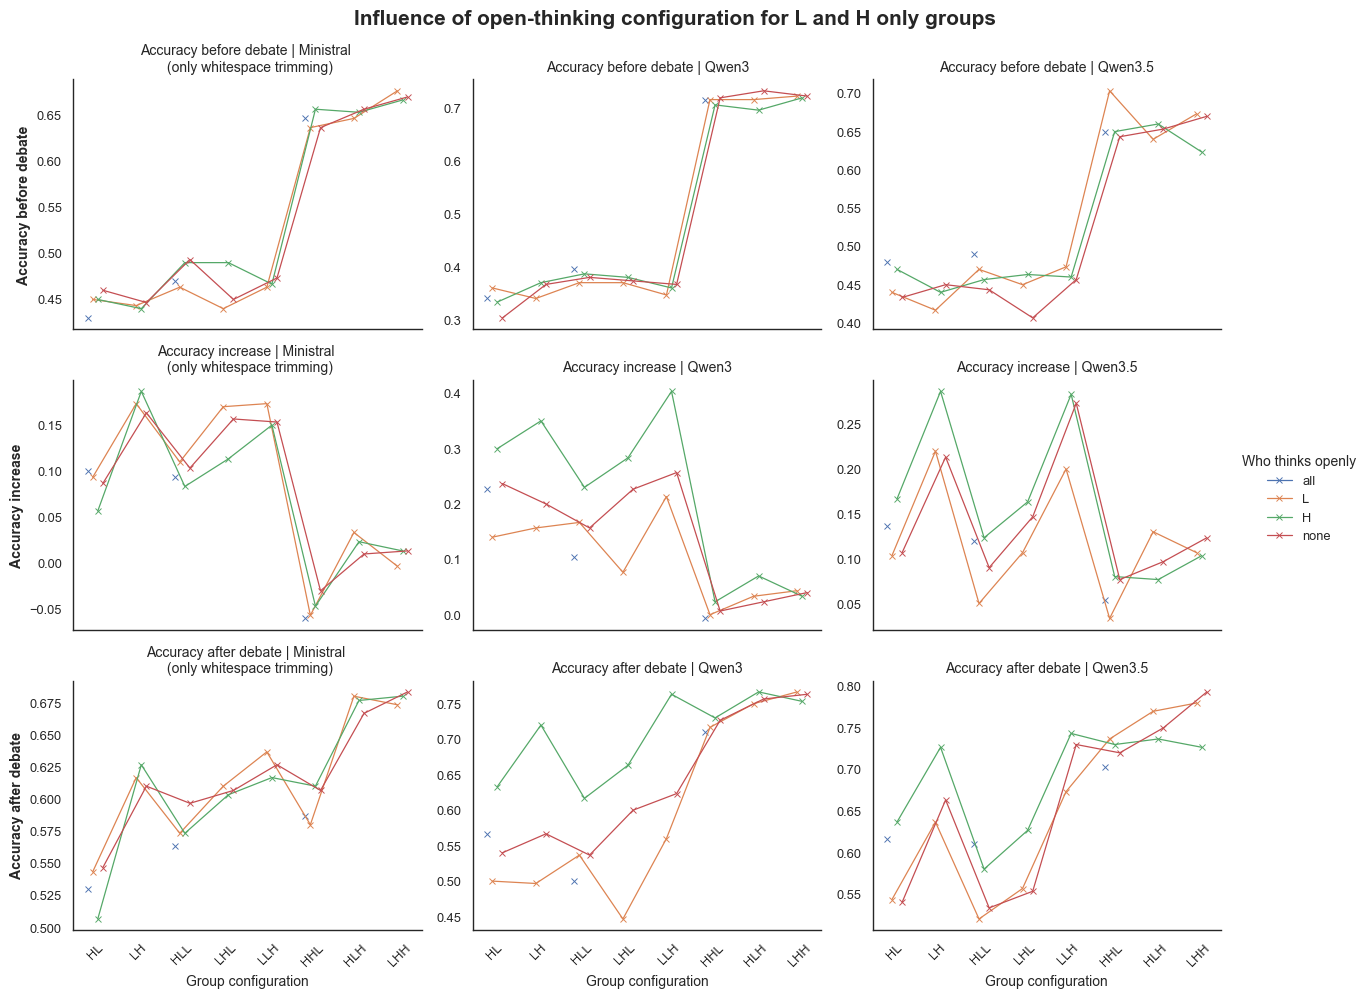

In [18]:
df = (
    thinking_mad_results.with_columns(
        pl.col("group_constellation")
        .str.split("")
        .list.sort()
        .list.join("")
        .alias("group_configuration")
    )
    .filter(
        pl.col("group_constellation")
        .str.split("")
        .list.unique()
        .list.sort()
        .list.join("")
        == "HL"
    )
    .sort(
        by=[
            pl.col("group_constellation").str.len_chars(),
            pl.col("group_constellation").str.split("").list.count_matches("L"),
            pl.col("group_constellation").str.split("").list.count_matches("h"),
        ]
    )
)

metrics = ["accuracy_before", "accuracy_increase", "accuracy"]

long = df.select(
    [
        "model_family",
        "group_constellation",
        "who_thinks_openly",
        *metrics,
    ]
).unpivot(
    index=[
        "model_family",
        "group_constellation",
        "who_thinks_openly",
    ],
    on=metrics,
    variable_name="metric",
    value_name="value",
)

pdf = long.to_pandas().sort_values(by="model_family")
config_order = sorted(
    pdf["group_constellation"].unique(),
    key=lambda x: (len(x), x.count("H"), x.count("L"), x),
)
who_order = ["all", "L", "H", "none"]

g = sns.catplot(
    data=pdf,
    kind="point",
    x="group_constellation",
    y="value",
    hue="who_thinks_openly",
    col="model_family",
    row="metric",
    order=config_order,
    hue_order=who_order,
    dodge=0.35,
    markers="x",
    linestyles="-",
    errorbar="sd",  # or ("ci", 95)
    height=3.2,
    aspect=1.3,
    sharey=False,
    linewidth=0.9,
    markersize=4.6,
    row_order=metrics,
)

g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_axis_labels("Group configuration", "")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)

# Replace row titles with prettier labels
for ax, metric in zip(g.axes[:, 0], metrics):
    ax.set_ylabel(metric_labels.get(metric, metric), fontweight="bold")

for i in range(len(g.axes[0])):
    for ax, metric in zip(g.axes[:, i], metrics):
        ax.set_title(
            ax._axes.title._text.replace(metric, metric_labels.get(metric, metric))
        )

g.figure.suptitle(
    "Influence of open-thinking configuration for L and H only groups",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)

g.legend.set_title("Who thinks openly")


register_materialization(
    "influence_of_open_thinking_config_for_LH_groups",
    g.figure,
    "influence_of_open_thinking_config_for_LH_groups",
    force=True,
)

In [19]:
thinking_mad_results

model_names,open_thinking_models,closed_thinking_models,model_family,closed_thinking_models_parameter,open_thinking_models_parameter,who_thinks_openly,group_size,group_constellation,accuracy,used_input_tokens,used_output_tokens,amount_parsing_errors_after,amount_parsing_errors_before,accuracy_before,call_cost_heuristic,accuracy_increase,wd_bias_good proposals,wd_bias_bad proposals,wd_bias_weight on one,wd_bias_False
list[str],list[str],list[str],str,list[f64],list[f64],str,u32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"[""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-4B""]","[null, null, null]","[""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-4B""]","""Qwen3.5""","[4.0, 9.0, 4.0]","[null, null, null]","""L""",3,"""MHM""",0.746667,61313.443333,29482.4,0.12,0.174444,0.69,102.0,0.056667,0.197164,0.38462,0.344714,0.290892
"[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B""]","[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B""]","[null, null]","""Qwen3""","[null, null]","[0.6, 0.6]","""L""",2,"""LL""",0.22,21061.63,6105.1,0.055,0.195,0.21,7.2,0.01,0.2604,0.44236,0.3496,0.35138
"[""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-4B""]","[null, ""Qwen/Qwen3.5-9B"", null]","[""Qwen/Qwen3.5-0.8B"", null, ""Qwen/Qwen3.5-4B""]","""Qwen3.5""","[0.8, null, 4.0]","[null, 9.0, null]","""H""",3,"""LHM""",0.746667,66097.6,24380.756667,0.143333,0.235556,0.636667,82.8,0.11,0.174956,0.366584,0.301372,0.27077
"[""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512""]","[null, null, null]","[""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512""]","""Ministral (only whitespace t…","[14.0, 14.0, 14.0]","[null, null, null]","""none""",3,"""HHH""",0.716667,28980.406667,5944.16,0.018889,0.061111,0.686667,252.0,0.03,0.174199,0.40152,0.302404,0.287859
"[""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-4B""]","[null, null, null]","[""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-4B""]","""Qwen3.5""","[4.0, 9.0, 4.0]","[null, null, null]","""none""",3,"""MHM""",0.75,61046.283333,29702.346667,0.131111,0.183333,0.68,102.0,0.07,0.200271,0.373413,0.363714,0.286842
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"[""Qwen/Qwen3-4B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B""]","[null, null, ""Qwen/Qwen3-14B""]","[""Qwen/Qwen3-4B"", ""Qwen/Qwen3-0.6B"", null]","""Qwen3""","[4.0, 0.6, null]","[null, null, 14.0]","""H""",3,"""MLH""",0.776667,28978.406667,7968.533333,0.023333,0.108889,0.653333,111.6,0.123333,0.138012,0.358895,0.252593,0.248453
"[""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-0.8B""]","[null, null, null]","[""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-0.8B""]","""Qwen3.5""","[9.0, 9.0, 0.8]","[null, null, null]","""none""",3,"""HHL""",0.72,56085.9,24341.75,0.155556,0.211111,0.643333,112.8,0.076667,0.206367,0.390362,0.347231,0.298365
"[""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-4B""]","[null, null]","[""Qwen/Qwen3.5-4B"", ""Qwen/Qwen3.5-4B""]","""Qwen3.5""","[4.0, 4.0]","[null, null]","""L""",2,"""MM""",0.676667,34072.66,20253.076667,0.123333,0.175,0.606667,48.0,0.07,0.173542,0.339723,0.215085,0.256632


In [20]:
import polars as pl

ANSWER_COL = plc.parsed_individual_answers_before
GOLD_COL = "answer_string"  # change if needed

# ------------------------------------------------------------
# 1. Expand all list positions using max length
# ------------------------------------------------------------

long = (
    thinking_mad_parsed.with_row_index("source_row_id")
    .with_columns(
        n_model_names=pl.col("model_names").list.len(),
        n_answers=pl.col(ANSWER_COL).list.len(),
    )
    .with_columns(n_slots=pl.max_horizontal("n_model_names"))
    .with_columns(list_idx=pl.int_ranges(0, pl.col("n_slots")))
    .explode("list_idx")
    .with_columns(
        model_name=pl.col("model_names").list.get(
            pl.col("list_idx"),
            null_on_oob=True,
        ),
        answer=pl.col(ANSWER_COL).list.get(
            pl.col("list_idx"),
            null_on_oob=True,
        ),
    )
    .with_columns(is_correct=(pl.col("answer") == pl.col(GOLD_COL)).cast(pl.Int64))
)

assert (
    len(long.filter(pl.col("model_name").is_null() | pl.col("answer").is_null())) == 0
)

# ------------------------------------------------------------
# 2. Accuracy for each model and each stochastic run
#    This answers:
#    "If this model answered the full test set once,
#     what was its total accuracy?"
# ------------------------------------------------------------

per_model_run = (
    long.group_by(["model_name", "run_id"])
    .agg(
        n_questions=pl.col("question_id").n_unique(),
        n_attempts=pl.len(),
        n_correct=pl.sum("is_correct"),
        accuracy=pl.mean("is_correct"),
    )
    .sort(["model_name", "run_id"])
)

# ------------------------------------------------------------
# 3. Final model-level summary across stochastic runs
# ------------------------------------------------------------

per_model_performance = (
    per_model_run.group_by("model_name")
    .agg(
        n_runs=pl.len(),
        # mean_n_questions=pl.mean("n_questions"),
        # min_n_questions=pl.min("n_questions"),
        # max_n_questions=pl.max("n_questions"),
        mean_accuracy=pl.mean("accuracy"),
        std_accuracy_across_runs=pl.std("accuracy"),
        # se_accuracy=pl.std("accuracy") / pl.len().sqrt(),
        min_accuracy=pl.min("accuracy"),
        max_accuracy=pl.max("accuracy"),
    )
    # .with_columns(
    #     ci95_low=pl.col("mean_accuracy") - 1.96 * pl.col("se_accuracy"),
    #     ci95_high=pl.col("mean_accuracy") + 1.96 * pl.col("se_accuracy"),
    # )
    .sort("mean_accuracy", descending=True)
)

per_model_performance

model_name,n_runs,mean_accuracy,std_accuracy_across_runs,min_accuracy,max_accuracy
str,u32,f64,f64,f64,f64
"""Qwen/Qwen3-14B""",81,0.739294,0.011265,0.706667,0.773333
"""Qwen/Qwen3.5-9B""",81,0.667332,0.013859,0.64,0.706667
"""mistralai/Ministral-3-14B-Reas…",81,0.66037,0.011522,0.636667,0.686667
"""Qwen/Qwen3-4B""",81,0.651296,0.01256,0.606667,0.68
"""Qwen/Qwen3.5-4B""",81,0.627051,0.014228,0.593333,0.67
"""mistralai/Ministral-3-8B-Reaso…",81,0.550453,0.011773,0.521667,0.583333
"""mistralai/Ministral-3-3B-Reaso…",81,0.382901,0.010682,0.36,0.406667
"""Qwen/Qwen3.5-0.8B""",81,0.276241,0.014104,0.243333,0.318333
"""Qwen/Qwen3-0.6B""",81,0.244342,0.014629,0.193333,0.28


In [21]:
thinking_mad_results.filter(pl.col("who_thinks_openly") == "H").filter(pl.col("group_constellation") == "LLH")

model_names,open_thinking_models,closed_thinking_models,model_family,closed_thinking_models_parameter,open_thinking_models_parameter,who_thinks_openly,group_size,group_constellation,accuracy,used_input_tokens,used_output_tokens,amount_parsing_errors_after,amount_parsing_errors_before,accuracy_before,call_cost_heuristic,accuracy_increase,wd_bias_good proposals,wd_bias_bad proposals,wd_bias_weight on one,wd_bias_False
list[str],list[str],list[str],str,list[f64],list[f64],str,u32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"[""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-9B""]","[null, null, ""Qwen/Qwen3.5-9B""]","[""Qwen/Qwen3.5-0.8B"", ""Qwen/Qwen3.5-0.8B"", null]","""Qwen3.5""","[0.8, 0.8, null]","[null, null, 9.0]","""H""",3,"""LLH""",0.743333,58424.216667,17471.373333,0.11,0.292222,0.46,63.6,0.283333,0.110649,0.272877,0.154884,0.191763
"[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-14B""]","[null, null, ""Qwen/Qwen3-14B""]","[""Qwen/Qwen3-0.6B"", ""Qwen/Qwen3-0.6B"", null]","""Qwen3""","[0.6, 0.6, null]","[null, null, 14.0]","""H""",3,"""LLH""",0.763333,31167.883333,8214.883333,0.025556,0.146667,0.36,91.2,0.403333,0.107275,0.297218,0.114206,0.202246
"[""mistralai/Ministral-3-3B-Reasoning-2512"", ""mistralai/Ministral-3-3B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512""]","[null, null, ""mistralai/Ministral-3-14B-Reasoning-2512""]","[""mistralai/Ministral-3-3B-Reasoning-2512"", ""mistralai/Ministral-3-3B-Reasoning-2512"", null]","""Ministral (only whitespace t…","[3.0, 3.0, null]","[null, null, 14.0]","""H""",3,"""LLH""",0.616667,29770.71,6079.133333,0.102222,0.135556,0.466667,120.0,0.15,0.230245,0.414678,0.272883,0.322461


In [22]:
thinking_mad_results.filter(pl.col("who_thinks_openly") == "H").filter(pl.col("group_constellation") == "HHH")

model_names,open_thinking_models,closed_thinking_models,model_family,closed_thinking_models_parameter,open_thinking_models_parameter,who_thinks_openly,group_size,group_constellation,accuracy,used_input_tokens,used_output_tokens,amount_parsing_errors_after,amount_parsing_errors_before,accuracy_before,call_cost_heuristic,accuracy_increase,wd_bias_good proposals,wd_bias_bad proposals,wd_bias_weight on one,wd_bias_False
list[str],list[str],list[str],str,list[f64],list[f64],str,u32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"[""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B""]","[""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B"", ""Qwen/Qwen3.5-9B""]","[null, null, null]","""Qwen3.5""","[null, null, null]","[9.0, 9.0, 9.0]","""H""",3,"""HHH""",0.73,81973.266667,29351.133333,0.181111,0.158889,0.696667,162.0,0.033333,0.233278,0.359241,0.271066,0.29626
"[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]","[""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B"", ""Qwen/Qwen3-14B""]","[null, null, null]","""Qwen3""","[null, null, null]","[14.0, 14.0, 14.0]","""H""",3,"""HHH""",0.79,35459.29,8841.566667,0.032222,0.066667,0.753333,252.0,0.036667,0.148199,0.375803,0.288121,0.262001
"[""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512""]","[""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512"", ""mistralai/Ministral-3-14B-Reasoning-2512""]","[null, null, null]","""Ministral (only whitespace t…","[null, null, null]","[14.0, 14.0, 14.0]","""H""",3,"""HHH""",0.696667,29135.546667,6023.696667,0.024444,0.066667,0.69,252.0,0.006667,0.193722,0.409521,0.340959,0.301622


In [23]:
per_model_performance["model_name"].to_list()

['Qwen/Qwen3-14B',
 'Qwen/Qwen3.5-9B',
 'mistralai/Ministral-3-14B-Reasoning-2512',
 'Qwen/Qwen3-4B',
 'Qwen/Qwen3.5-4B',
 'mistralai/Ministral-3-8B-Reasoning-2512',
 'mistralai/Ministral-3-3B-Reasoning-2512',
 'Qwen/Qwen3.5-0.8B',
 'Qwen/Qwen3-0.6B']